In [ ]:
import os
from pathlib import Path
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import configparser
from tqdm import tqdm
from torchvision.models import resnet18, resnet34
import torch.nn as nn
from torch import optim
from torch.optim.lr_scheduler import StepLR
import copy
import time
import matplotlib.pyplot as plt
import pickle

# torch.cuda.empty_cache()

# Limitar el uso de memoria de la GPU al 50%
# torch.cuda.set_per_process_memory_fraction(0.5, 0)  # 50% para este proceso

In [2]:
data_path = Path(os.getcwd()).parent

In [3]:
# listado de imagenes para cada dataset
data_config = configparser.ConfigParser()
data_config.read(data_path/'data/splits/global_binaria.ini')

['c:\\Users\\gabim\\MiM\\data\\splits\\global_binaria.ini']

# Media y desvío de intensidad para cada canal

In [23]:
images_path = data_config['split'].get('training').split(sep=',')
count = len(images_path)*512*512

In [24]:
to_tensor = transforms.ToTensor() # esta transformacion aplica torch.tensor, deja las intensidades en el rango de 0 a 1 si ve que la entrada es de 0 a 255
                                  # y acomoda los indices como espera recibirlos pytorch (canales,alto,ancho)

sum_by_channel = torch.zeros(3) # creo un tensor de ceros para guardar la media de los 3 canales

for image in tqdm(images_path):
    img = cv2.imread(data_path/'data/images'/(image+'.png'))
    img = to_tensor(img)
    img = img.view(3,-1).sum(dim=1) # en la primera dimension que son los canales le pedimos que queden los 3 pero el resto de las dimensiones (alto, ancho)
                                    # le pedimos que las apile en una dimension y que sume las intensidades de cada canal
    sum_by_channel += img


img_mean = sum_by_channel/count
img_mean

  0%|          | 0/41978 [00:00<?, ?it/s]


NameError: name 'cv2' is not defined

In [ ]:
sum_desv_by_channel = torch.zeros(3)

for image in tqdm(images_path):
    img = cv2.imread(data_path/'data/images'/(image+'.png'))
    img = to_tensor(img)
    img = img.view(3,-1)
    img = (img - img_mean.view(3,1))**2
    img = img.sum(dim=1)
    sum_desv_by_channel += img

img_std = (sum_desv_by_channel/count)**0.5
img_std

100%|██████████| 41978/41978 [03:02<00:00, 229.77it/s]


tensor([0.1661, 0.2021, 0.2782])

# Clase Dataset

In [4]:
class EyeDataset(Dataset):
  
  def __init__(self, data_path, partition, mean, std, transformations=None):
    '''
    - data_path: ruta base donde están las imágenes y configuraciones
    - partition: 'training', 'validation' o 'test'
    - mean: media para normalizar los datos
    - std: desvío estándar
    - transformations: la lista de transformaciones a aplicar al dataset de train
    '''

    # chequeo que no entre cualquier cosa en vez de partition
    assert partition in ['training', 'validation', 'test'], 'partition has to be training, validation or test, not {}'.format(partition)

    # transformaciones
    data_transforms = [transforms.ToTensor(),
                       transforms.Normalize(mean=mean, std=std)]
    
    if (partition == 'training') and not (transformations is None):
      data_transforms = transformations + data_transforms
      
    self.data_transforms = transforms.Compose(data_transforms)
    
    self.data_path = Path(data_path)

    # listado de imagenes para cada dataset
    data_config = configparser.ConfigParser()
    data_config.read(self.data_path/'data/splits/global_binaria.ini')

    # listado de labels para cada imagen
    labels_config = configparser.ConfigParser()
    labels_config.read(self.data_path/'data/labels/global_labels.ini')

    self.data = [(image, int(labels_config['label'].get(image)))
                  for image in data_config['split'].get(partition).split(sep=',')
                  ]
    
    # hacemos una lista de nombres para las clases
    self.class_names = ['buena', 'mala']


  def __len__(self):
    '''
    Método que devuelve la cantidad de elementos del dataset
    '''
    return len(self.data)
  
  def __getitem__(self, index):
    '''
    Método que devuelve el elemento index del dataset
    '''
    # obtengo la ruta de la imagen y su etiqueta asociada
    img_path, label = self.data[index]

    # cargo la imagen
    img = Image.open(self.data_path/'data/images'/(img_path+'.png')).convert("RGB") # uso PIL porque es compatible con transforms. Importa la imagen en el formato que espera pytorch 
                                                                                    # y aclaro RGB porque PIL importa en el formato original y puede no ser RGB qu es lo que espera pytorch
    # transformaciones
    img = self.data_transforms(img)

    # convierto la etiqueta en un tensor de tipo long
    label = torch.tensor(label, dtype=torch.long)

    # retornamos el par
    return (img, label)

In [5]:
mean=torch.tensor([0.1948, 0.2880, 0.4238])
std=torch.tensor([0.1661, 0.2021, 0.2782])

In [6]:
transformations = [transforms.RandomHorizontalFlip(p=0.5),
                   transforms.RandomRotation(degrees=[-15,15], interpolation=transforms.InterpolationMode.BILINEAR,fill=(0, 0, 0)),
                   transforms.RandomVerticalFlip(p=0.5),
                   # transforms.RandomResizedCrop(size=512, scale=(0.8, 1.0))
                   ]


training_set = EyeDataset(data_path=Path(os.getcwd()).parent,
                          partition='training',
                          mean=mean,
                          std=std,
                          transformations=transformations)

validation_set = EyeDataset(data_path=Path(os.getcwd()).parent,
                            partition='validation',
                            mean=mean,
                            std=std)

In [7]:
image_datasets = {'train':training_set,
                  'val': validation_set}

In [8]:
len(training_set)

41978

# Dataloader

In [9]:
# La clase dataloader sirve para armar batches de imagenes
# Si es train queremos que agarre las imagenes de forma aleatoria (shuffle)
dataloaders = {x: DataLoader(image_datasets[x], batch_size=128, num_workers=0, pin_memory=True, shuffle=(x=='train')) for x in ['train', 'val']}
# probe con num_workers >0 y termina tardando mucho mas

In [10]:
# tamaño de cada dataset completo
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

In [11]:
len(dataloaders['train']) # consulto la cantidad de batches de train

328

In [12]:
len(dataloaders['val']) # consulto la cantidad de batches de train

107

In [13]:
dataset_sizes

{'train': 41978, 'val': 13651}

# Training loop

In [14]:
def train_model(model, loss_fn, optimizer, scheduler, dataloaders, dataset_sizes, device, num_epochs=25):

  torch.backends.cudnn.benchmark = True  # Optimiza convoluciones para imágenes de tamaño fijo

  since =  time.time()
  
  # trae los pesos del modelo
  best_model_wts = copy.deepcopy(model.state_dict())
  # inicializamos el mejor accuracy en 0
  best_acc = 0
  # guardamos los valores de loss y acc por epoca para graficarlos
  loss_per_epoch = { x: [] for x in ['train', 'val']}
  accuracy_per_epoch = { x: [] for x in ['train', 'val']}

  scaler = torch.amp.GradScaler('cuda')  # Agregado para AMP

  for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-'*10)

    for phase in ['train', 'val']:
      if phase == 'train':
        model.train() # pone el modelo en modo train
      else:
        model.eval()

      # para ir guardando la evolucion de la loss
      running_loss = 0.0
      # para ir guardando la cantidad de muestras clasificadas correctamente
      running_corrects = 0

      # iteramos sobre los datos
      for inputs, labels in dataloaders[phase]:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # manda a 0 los gradientes
        optimizer.zero_grad()

        # forward pass
        with torch.set_grad_enabled(phase == 'train'):
          with torch.amp.autocast("cuda"):  # Precisión mixta
            outputs = model(inputs)
            _, preds = torch.max(outputs,1)
            loss = loss_fn(outputs, labels)

          # backward pass
          if phase == 'train':
            # loss.backward()
            # optimizer.step()
            scaler.scale(loss).backward()  # Escala el gradiente
            scaler.step(optimizer)  # Aplica el paso de optimización
            scaler.update()  # Ajusta la escala dinámicamente

        # guardamos las estadisticas
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

      # actualizar el planificador de la LR si estamos en train
      if phase == 'train':
        scheduler.step()

      # loss y acc de la epoca
      epoch_loss = running_loss / dataset_sizes[phase]
      epoch_acc = running_corrects.double() / dataset_sizes[phase]
      loss_per_epoch[phase].append(epoch_loss)
      accuracy_per_epoch[phase].append(epoch_acc.item())

      print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

      # si la performance mejoró respecto a lo anterior se copia el modelo
      if phase == 'val' and epoch_acc > best_acc:
        best_acc = epoch_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print('')

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best val Acc: {:4f}'.format(best_acc))

  # carga el mejor modelo y lo devuelve
  model.load_state_dict(best_model_wts)
  return model, loss_per_epoch, accuracy_per_epoch

Cómo funciona AMP sin perder precisión
PyTorch usa float16 solo en operaciones que no necesitan tanta precisión, como multiplicaciones de matrices.
Algunas operaciones críticas (como la suma de gradientes) siguen en float32 para evitar errores numéricos.
Si un número en float16 es demasiado pequeño o grande, AMP lo escala automáticamente con GradScaler para que no se pierda información.

In [15]:
def plot_training_statistics(training_loss_per_epoch, validation_loss_per_epoch, training_accuracy_per_epoch, validation_accuracy_per_epoch):
  '''
  Plotea las estadísticas sobre datos de entrenamiento y validación
  (loss function y valores de accuracy)
  '''

  # creamos plots para la loss y el accuracy
  fig, axes = plt.subplots(1, 2)
  # graficamos la evolución de la loss de entrenamiento y la de validación
  axes[0].plot(training_loss_per_epoch, color='blue')
  axes[0].plot(validation_loss_per_epoch, color='red')
  axes[0].set_xlabel('Epochs')
  axes[0].set_ylabel('Cross entropy loss')
  axes[0].grid(True)
  axes[0].legend(['Training set', 'Validation set'])
  axes[0].set_title('Loss function')
  # graficamos la evolución del accuracy en los datos de entrenamiento y validación
  axes[1].plot(training_accuracy_per_epoch, color='blue')
  axes[1].plot(validation_accuracy_per_epoch, color='red')
  axes[1].set_xlabel('Epochs')
  axes[1].set_ylabel('Accuracy')
  axes[1].grid(True)
  axes[1].legend(['Training set', 'Validation set'])
  axes[1].set_title('Accuracy')
  axes[1].set_ylim([0, 1.0])
  fig.tight_layout(pad=3.0)

# ResNet Pretrained

## ResNet18

In [16]:
# Importo la ResNet18 y sus pesos
model18 = resnet18(pretrained=True)

c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [17]:
model18 # estructura de la red

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
model18.state_dict() # muestra los pesos

OrderedDict([('conv1.weight',
              tensor([[[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  ...,  5.6615e-02,
                          1.7083e-02, -1.2694e-02],
                        [ 1.1083e-02,  9.5276e-03, -1.0993e-01,  ..., -2.7124e-01,
                         -1.2907e-01,  3.7424e-03],
                        [-6.9434e-03,  5.9089e-02,  2.9548e-01,  ...,  5.1972e-01,
                          2.5632e-01,  6.3573e-02],
                        ...,
                        [-2.7535e-02,  1.6045e-02,  7.2595e-02,  ..., -3.3285e-01,
                         -4.2058e-01, -2.5781e-01],
                        [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  ...,  4.1384e-01,
                          3.9359e-01,  1.6606e-01],
                        [-1.3736e-02, -3.6746e-03, -2.4084e-02,  ..., -1.5070e-01,
                         -8.2230e-02, -5.7828e-03]],
              
                       [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  ...,  3.2521e-02,
                          6.6221

In [19]:
# recorro todos los parámetros y los congelo
for param in model18.parameters():
  param.requires_grad = False

In [20]:
# nro de features de salida porque la ResNet se entreno para el dataset ImageNet que tiene 1000 clases.
num_ftrs = model18.fc.in_features
# creo la capa de clasificacion para la clasificaion binaria de imagenes de la retina
model18.fc = nn.Linear(num_ftrs, 2)

In [21]:
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')

device

device(type='cuda', index=0)

In [22]:
# pasa el modelo a la GPU
model18 = model18.to(device)

In [23]:
loss_fn = nn.CrossEntropyLoss()

# inicializa el optimizer pasandole solamente los parametros que no estan freezados
# o sea los de la ultima capa que agregue
parameters_to_train = filter(lambda p: p.requires_grad, model18.parameters())
optimizer = optim.SGD(parameters_to_train, lr=0.001, momentum=0.9)

In [24]:
for name, param in model18.named_parameters():
    print(f"{name}: {'Entrenable' if param.requires_grad else 'Congelado'}")

conv1.weight: Congelado
bn1.weight: Congelado
bn1.bias: Congelado
layer1.0.conv1.weight: Congelado
layer1.0.bn1.weight: Congelado
layer1.0.bn1.bias: Congelado
layer1.0.conv2.weight: Congelado
layer1.0.bn2.weight: Congelado
layer1.0.bn2.bias: Congelado
layer1.1.conv1.weight: Congelado
layer1.1.bn1.weight: Congelado
layer1.1.bn1.bias: Congelado
layer1.1.conv2.weight: Congelado
layer1.1.bn2.weight: Congelado
layer1.1.bn2.bias: Congelado
layer2.0.conv1.weight: Congelado
layer2.0.bn1.weight: Congelado
layer2.0.bn1.bias: Congelado
layer2.0.conv2.weight: Congelado
layer2.0.bn2.weight: Congelado
layer2.0.bn2.bias: Congelado
layer2.0.downsample.0.weight: Congelado
layer2.0.downsample.1.weight: Congelado
layer2.0.downsample.1.bias: Congelado
layer2.1.conv1.weight: Congelado
layer2.1.bn1.weight: Congelado
layer2.1.bn1.bias: Congelado
layer2.1.conv2.weight: Congelado
layer2.1.bn2.weight: Congelado
layer2.1.bn2.bias: Congelado
layer3.0.conv1.weight: Congelado
layer3.0.bn1.weight: Congelado
layer3.0

In [ ]:
# y el reductor de learning rate cada 5 epocas
exp_lr_scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

In [26]:
# entrenamos el modelo esto es con batch_size=128, num_workers=0, pin_memory=True y con pesos de la 18 y entrenando solo la fc
# este seria el baseline model. OJO que como era 25 epocas le puse el step de optimizer cada 5. El otro entrenamiento ya lo habia arrancado por
# eso no lo cambie
model, loss_per_epoch, accuracy_per_epoch =  train_model(model18,
                                                              loss_fn,
                                                              optimizer,
                                                              exp_lr_scheduler,
                                                              dataloaders,
                                                              dataset_sizes,
                                                              device,
                                                              25)

Epoch 1/25
----------
train Loss: 0.1278 Acc: 0.9591
val Loss: 0.0823 Acc: 0.9747

Epoch 2/25
----------
train Loss: 0.0915 Acc: 0.9694
val Loss: 0.0714 Acc: 0.9755

Epoch 3/25
----------
train Loss: 0.0862 Acc: 0.9701
val Loss: 0.0760 Acc: 0.9747

Epoch 4/25
----------
train Loss: 0.0839 Acc: 0.9710
val Loss: 0.0703 Acc: 0.9755

Epoch 5/25
----------
train Loss: 0.0816 Acc: 0.9720
val Loss: 0.0668 Acc: 0.9759

Epoch 6/25
----------
train Loss: 0.0804 Acc: 0.9719
val Loss: 0.0665 Acc: 0.9761

Epoch 7/25
----------
train Loss: 0.0804 Acc: 0.9720
val Loss: 0.0669 Acc: 0.9762

Epoch 8/25
----------
train Loss: 0.0803 Acc: 0.9720
val Loss: 0.0691 Acc: 0.9760

Epoch 9/25
----------
train Loss: 0.0792 Acc: 0.9723
val Loss: 0.0680 Acc: 0.9760

Epoch 10/25
----------
train Loss: 0.0798 Acc: 0.9720
val Loss: 0.0682 Acc: 0.9758

Epoch 11/25
----------
train Loss: 0.0801 Acc: 0.9721
val Loss: 0.0680 Acc: 0.9759

Epoch 12/25
----------
train Loss: 0.0801 Acc: 0.9722
val Loss: 0.0678 Acc: 0.9760

E

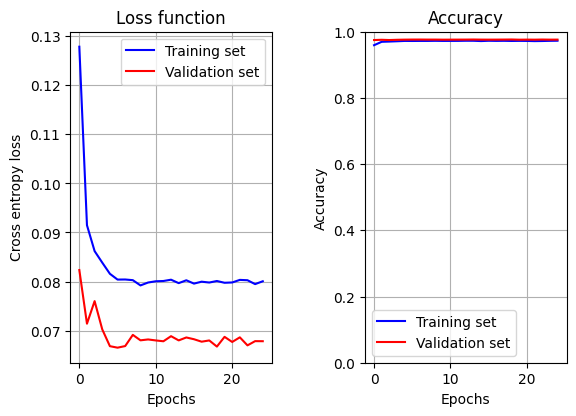

In [27]:
plot_training_statistics(loss_per_epoch['train'], loss_per_epoch['val'], accuracy_per_epoch['train'], accuracy_per_epoch['val'])

In [ ]:
import pickle
# Guardar el modelo
torch.save(model.state_dict(), "best_batch128_weights18_fc.pth")

# Guardar los diccionarios de pérdidas y precisión
data = {
    "loss_per_epoch": loss_per_epoch,
    "accuracy_per_epoch": accuracy_per_epoch
}

with open("metrics_batch128_weights18_fc.pkl", "wb") as f:
    pickle.dump(data, f)


## Usar pesos de la ResNet34

In [17]:
model18 = resnet18(pretrained=True)
model34 = resnet34(pretrained=True)

c:\Users\gabim\anaconda3\envs\mim_entorno\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
model34

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
# Obtener los pesos de la ResNet34
state_dict_resnet34 = model34.state_dict()

# Filtrar solo los pesos que existen en la ResNet18
state_dict_resnet18 = {k: v for k, v in state_dict_resnet34.items() if k in model18.state_dict()}

# Cargar los pesos en la ResNet18
model18.load_state_dict(state_dict_resnet18, strict=False)

<All keys matched successfully>

In [ ]:
model18.state_dict() # muestra los pesos

OrderedDict([('conv1.weight',
              tensor([[[[ 5.4109e-03, -6.9092e-03,  7.8839e-03,  ...,  4.9072e-02,
                          3.0660e-02,  2.5398e-02],
                        [ 4.1081e-02,  3.1296e-02,  3.2265e-02,  ...,  3.3145e-02,
                          2.9754e-02,  4.1735e-02],
                        [ 4.9519e-03, -3.1705e-02, -6.1310e-02,  ..., -9.7493e-02,
                         -1.1601e-01, -1.2191e-01],
                        ...,
                        [-1.2287e-02, -2.4841e-02, -9.3052e-03,  ...,  1.7113e-02,
                          2.4631e-03,  1.6726e-02],
                        [ 3.9117e-03,  4.4537e-03,  3.6315e-02,  ...,  1.0371e-01,
                          7.3973e-02,  5.9085e-02],
                        [ 1.6784e-02,  8.8902e-03,  3.1312e-02,  ...,  9.6964e-02,
                          8.3749e-02,  9.6970e-02]],
              
                       [[-7.7192e-03, -8.7711e-03,  1.4143e-02,  ...,  3.3901e-02,
                          2.5483

In [34]:
# recorro todos los parámetros y los congelo
for param in model18.parameters():
  param.requires_grad = False

In [35]:
for param in model18.layer4.parameters():  # Descongelar la última capa convolucional
    param.requires_grad = True

for param in model18.layer3.parameters():  # Descongelar la última capa convolucional
    param.requires_grad = True

In [36]:
# nro de features de salida porque la ResNet se entreno para el dataset ImageNet que tiene 1000 clases.
num_ftrs = model18.fc.in_features
# creo la capa de clasificacion para la clasificaion binaria de imagenes de la retina
model18.fc = nn.Linear(num_ftrs, 2)

In [37]:
if torch.cuda.is_available():
  device = torch.device('cuda:0')
else:
  device = torch.device('cpu')

In [38]:
device

device(type='cuda', index=0)

In [39]:
# pasa el modelo a la GPU
model18 = model18.to(device)

In [40]:
loss_fn = nn.CrossEntropyLoss()

# inicializa el optimizer pasandole solamente los parametros que no estan freezados
# o sea los de la ultima capa que agregue
parameters_to_train = filter(lambda p: p.requires_grad, model18.parameters())
optimizer = optim.SGD(parameters_to_train, lr=0.001, momentum=0.9)

In [41]:
for name, param in model18.named_parameters():
    print(f"{name}: {'Entrenable' if param.requires_grad else 'Congelado'}")

conv1.weight: Congelado
bn1.weight: Congelado
bn1.bias: Congelado
layer1.0.conv1.weight: Congelado
layer1.0.bn1.weight: Congelado
layer1.0.bn1.bias: Congelado
layer1.0.conv2.weight: Congelado
layer1.0.bn2.weight: Congelado
layer1.0.bn2.bias: Congelado
layer1.1.conv1.weight: Congelado
layer1.1.bn1.weight: Congelado
layer1.1.bn1.bias: Congelado
layer1.1.conv2.weight: Congelado
layer1.1.bn2.weight: Congelado
layer1.1.bn2.bias: Congelado
layer2.0.conv1.weight: Congelado
layer2.0.bn1.weight: Congelado
layer2.0.bn1.bias: Congelado
layer2.0.conv2.weight: Congelado
layer2.0.bn2.weight: Congelado
layer2.0.bn2.bias: Congelado
layer2.0.downsample.0.weight: Congelado
layer2.0.downsample.1.weight: Congelado
layer2.0.downsample.1.bias: Congelado
layer2.1.conv1.weight: Congelado
layer2.1.bn1.weight: Congelado
layer2.1.bn1.bias: Congelado
layer2.1.conv2.weight: Congelado
layer2.1.bn2.weight: Congelado
layer2.1.bn2.bias: Congelado
layer3.0.conv1.weight: Entrenable
layer3.0.bn1.weight: Entrenable
layer3

In [42]:
# y el reductor de learning rate cada 7 epocas
exp_lr_scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

In [43]:
# entrenamos el modelo esto es con batch_size=64, num_workers=0, pin_memory=True y con pesos de la 18 y entrenando la capa 3 Y 4 y la fc
model, loss_per_epoch, accuracy_per_epoch =  train_model(model18,
                                                              loss_fn,
                                                              optimizer,
                                                              exp_lr_scheduler,
                                                              dataloaders,
                                                              dataset_sizes,
                                                              device,
                                                              1)

Epoch 1/1
----------
train Loss: 0.0921 Acc: 0.9693
val Loss: 0.0572 Acc: 0.9781

Training complete in 45m 40s
Best val Acc: 0.978097


In [32]:
# DESCARTADO PORQUE NO AGREGA TANTO VALOR
# entrenamos el modelo esto es con batch_size=64, num_workers=0, pin_memory=True y con pesos de la 34 y entrenando la capa 4 y la fc
model, loss_per_epoch, accuracy_per_epoch =  train_model(model18,
                                                              loss_fn,
                                                              optimizer,
                                                              exp_lr_scheduler,
                                                              dataloaders,
                                                              dataset_sizes,
                                                              device,
                                                              1)

Epoch 1/1
----------
train Loss: 0.1234 Acc: 0.9600
val Loss: 0.0826 Acc: 0.9723

Training complete in 35m 19s
Best val Acc: 0.972310


In [28]:
# entrenamos el modelo esto es con batch_size=64, num_workers=0, pin_memory=True y con pesos de la 18 y entrenando la capa 4 y la fc
model, loss_per_epoch, accuracy_per_epoch =  train_model(model18,
                                                              loss_fn,
                                                              optimizer,
                                                              exp_lr_scheduler,
                                                              dataloaders,
                                                              dataset_sizes,
                                                              device,
                                                              1)

Epoch 1/1
----------
train Loss: 0.0975 Acc: 0.9667
val Loss: 0.0596 Acc: 0.9777

Training complete in 45m 51s
Best val Acc: 0.977657
